In [ ]:
!pip install pandas -q
!pip install seaborn  -q

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


### EDA 

In [37]:
df = pd.read_csv("data/compustat.csv")

print(df.shape)


(620141, 58)


In [38]:
df.head()

,costat,curcdq,datafmt,indfmt,consol,tic,datadate,gvkey,conm,conml,...,xsgaq,capxy,dltisy,dvy,oancfy,oibdpy,scstkcy,mkvaltq,prchq,prclq
0,I,USD,STD,INDL,C,SERV.1,2010-01-31,1082,SERVIDYNE INC,Servidyne Inc,...,2.457,0.211,0.00,0.149,-1.274,-2.603,NaN,6.7252,2.300,1.530
1,I,USD,STD,INDL,C,AIM.1,2010-01-31,1173,AEROSONIC CORP,Aerosonic Corp,...,1.958,1.991,0.00,0.000,-0.032,4.895,NaN,14.7001,6.130,3.750
2,I,USD,STD,INDL,C,ACEL.,2010-01-31,1259,TAMIR BIOTHECHNOLOGY INC,Tamir Biotechnology Inc,...,0.489,0.002,3.25,0.000,-2.692,-1.022,NaN,8.9897,0.301,0.138
3,A,USD,STD,INDL,C,ABM,2010-01-31,1410,ABM INDUSTRIES INC,ABM Industries Inc,...,60.832,7.379,131.00,6.992,-8.913,32.669,NaN,1007.6067,21.650,17.940
4,I,USD,STD,INDL,C,LGTY,2010-01-31,1562,LOGILITY SPPLY CHAIN SOL INC,Logility Supply Chain Solutions Inc,...,8.196,0.418,0.00,6.835,-3.740,8.211,NaN,138.6659,6.750,5.440


In [39]:
print(df.duplicated().sum(), "duplicate rows found and deleted")
df = df.drop_duplicates()

0 duplicate rows found and deleted


In [40]:
num_companies = df['gvkey'].dropna().nunique()
print("Number of unique companies:", num_companies)

Number of unique companies: 21048


In [41]:
df['datadate'] = pd.to_datetime(df['datadate'])
df = df.sort_values(['gvkey', 'datadate'])

# year-quarter index
df['year'] = df['datadate'].dt.year
df['quarter'] = df['datadate'].dt.quarter


In [80]:
min_date = df['datadate'].min()
max_date = df['datadate'].max()

print(f"Initial date in dataset: {min_date}")
print(f"Last date in dataset: {max_date}")

Initial date in dataset: 2010-01-31 00:00:00
Last date in dataset: 2025-12-31 00:00:00


In [42]:
obs_per_firm = df.groupby('gvkey')['datadate'].count()

# Keep firms with at least 20 quarters (5 years)
valid_firms = obs_per_firm[obs_per_firm >= 12].index
df = df[df['gvkey'].isin(valid_firms)]


In [43]:
targets = ['oancfy', 'cheq']
#Operating Activities – Net Cash Flow (Year-to-Date) = The cumulative cash generated (or used) by operations from the beginning of the fiscal year up to that quarter.
#Cash and Short-Term Investments (Quarterly) = The firm's cash holdings at the end of the quarter.

df[targets].isna().mean()

oancfy    0.337925
cheq      0.316631
dtype: float64

In [44]:
missing = df.isna().mean().sort_values(ascending=False)

missing.head(15)

findltq    0.997650
udoltq     0.988637
scstkcy    0.973903
deraltq    0.890160
derlltq    0.868841
cshopq     0.684350
xrdq       0.680577
xaccq      0.665935
ipodate    0.584330
dd1q       0.529449
npq        0.475765
lltq       0.473970
drcq       0.472951
ivltq      0.460721
wcapq      0.450017
dtype: float64

### select one firm

In [ ]:
selected_gvkey = valid_firms[0]  
firm_df = df[df['gvkey'] == selected_gvkey].copy()

firm_df['datadate'] = pd.to_datetime(df['datadate'])
firm_df = firm_df.set_index('datadate').sort_index()

In [79]:
min_date = firm_df.index.min()
max_date = firm_df.index.max()

print(f"Minimum date: {min_date}")
print(f"Maximum date: {max_date}")

Minimum date: 2010-02-28 00:00:00
Maximum date: 2025-11-30 00:00:00


In [71]:
#tran test split
train = firm_df.iloc[:-4]
test = firm_df.iloc[-4:]

# Separate target
y_train = train['cheq']
y_test  = test['cheq']

# Drop target from feature matrix
X_train = train.drop(columns=['cheq'])
X_test  = test.drop(columns=['cheq'])

print("Selected firm:", selected_gvkey)
print("Training observations:", len(train))
print("Test observations:", len(test))

Selected firm: 1004
Training observations: 60
Test observations: 4


In [72]:
# Compute missing ratio in training set
missing_ratio = X_train.isnull().mean()

# Keep columns with <= 20% missing
cols_to_keep = missing_ratio[missing_ratio <= 0.20].index

X_train = X_train[cols_to_keep]
X_test  = X_test[cols_to_keep]

In [73]:
# Keep only numeric columns
X_train = X_train.select_dtypes(include=['number'])
X_test  = X_test[X_train.columns]

In [74]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

# Fit on training data
X_train_imputed = imputer.fit_transform(X_train)

# Transform test data
X_test_imputed = imputer.transform(X_test)

In [75]:
import numpy as np

# break data into 5 parts and check stationary

n_parts = 5
part_size = len(y_train) // n_parts

means = []
variances = []

for i in range(n_parts):
    start = i * part_size
    end = (i + 1) * part_size if i < n_parts - 1 else len(y_train)
    
    segment = y_train.iloc[start:end]
    means.append(segment.mean())
    variances.append(segment.var())

for i in range(n_parts):
    print(f"Part {i+1}: Mean = {means[i]:.3f}, Variance = {variances[i]:.3f}")

Part 1: Mean = 61.486, Variance = 518.505
Part 2: Mean = 75.300, Variance = 588.016
Part 3: Mean = 28.067, Variance = 219.448
Part 4: Mean = 99.225, Variance = 11255.989
Part 5: Mean = 69.033, Variance = 323.761


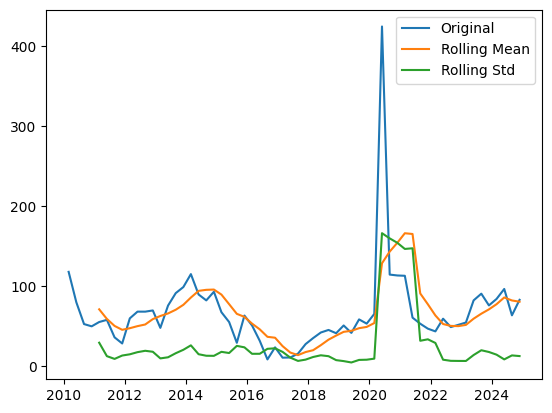

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

rolling_mean = y_train.rolling(window=5).mean()
rolling_std = y_train.rolling(window=5).std()

plt.plot(y_train, label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')
plt.legend()
plt.show()

In [83]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF
adf_result = adfuller(y_train)
print("ADF p-value:", adf_result[1])

# KPSS
from statsmodels.tsa.stattools import kpss
kpss_stat, p_value, _, _ = kpss(y_train)
print("KPSS p-value:", p_value)

ADF p-value: 1.0899808508573745e-06
KPSS p-value: 0.1


C:\Users\manoj\AppData\Local\Temp\ipykernel_2964\1110373166.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, p_value, _, _ = kpss(y_train)


### remove nonstationary traits

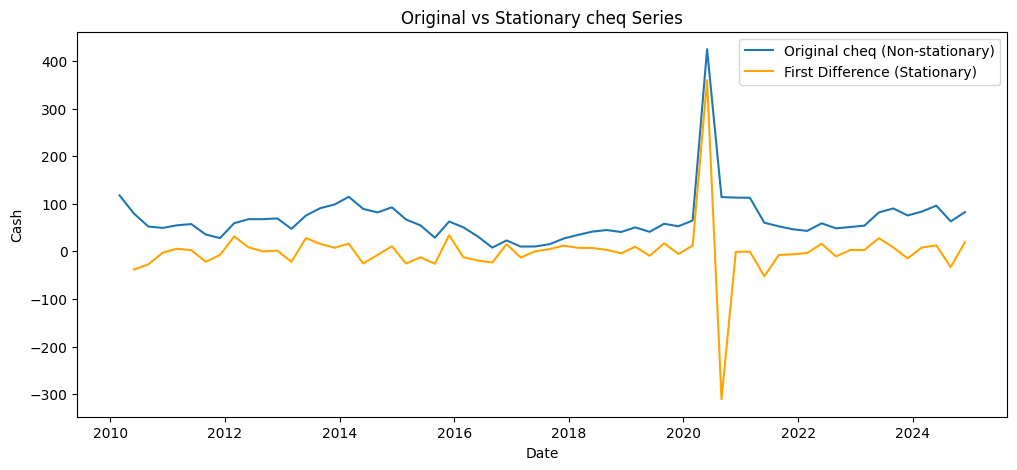

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

cheq_original = y_train.copy()
cheq_stationary = y_train.diff().dropna()

plt.figure(figsize=(12,5))

plt.plot(cheq_original.index, cheq_original, label='Original cheq (Non-stationary)')
plt.plot(cheq_stationary.index, cheq_stationary, label='First Difference (Stationary)', color='orange')

plt.title('Original vs Stationary cheq Series')
plt.xlabel('Date')
plt.ylabel('Cash')
plt.legend()
plt.show()

### fit arima

In [87]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Fit ARIMA (d=1 since cash is I(1))
model = ARIMA(y_train, order=(1,1,1))
model_fit = model.fit()

# Forecast same number of steps as test set
n_forecast = len(y_test)
forecast = model_fit.forecast(steps=n_forecast)

# Make forecast index equal to test index (important for plotting)
forecast.index = y_test.index

c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-NOV will be used.
  self._init_dates(dates, freq)
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-NOV will be used.
  self._init_dates(dates, freq)
c:\Users\manoj\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QE-NOV will be used.
  self._init_dates(dates, freq)


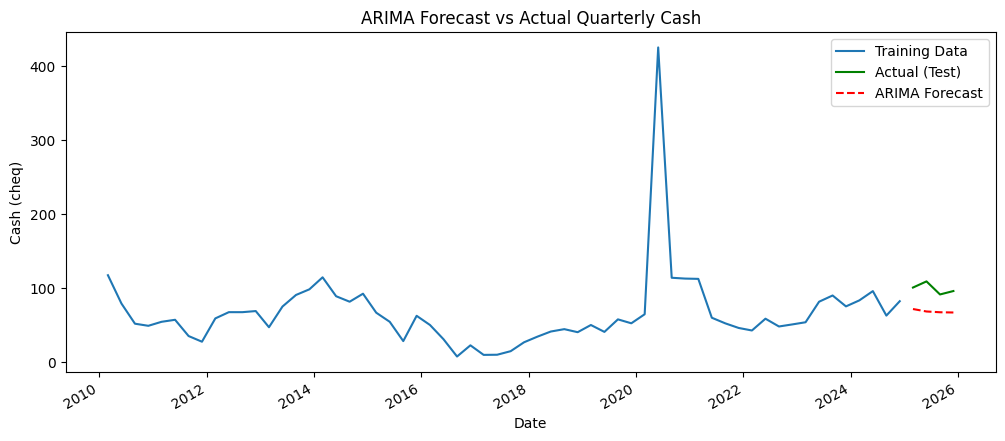

In [88]:
plt.figure(figsize=(12,5))

# Plot training data
plt.plot(y_train.index, y_train, label="Training Data")

# Plot actual test data
plt.plot(y_test.index, y_test, label="Actual (Test)", color="green")

# Plot forecast
plt.plot(forecast.index, forecast, label="ARIMA Forecast", color="red", linestyle="--")

plt.title("ARIMA Forecast vs Actual Quarterly Cash")
plt.xlabel("Date")
plt.ylabel("Cash (cheq)")
plt.legend()

plt.gcf().autofmt_xdate()
plt.show()

### Random forest regressor

In [95]:
import pandas as pd

# Convert imputed arrays back to DataFrame
X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns,
    index=X_train.index
)

X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=X_test.columns,
    index=X_test.index
)

# Create differenced target
y_train_diff = y_train.diff().dropna()

# Align features (drop first row)
X_train_aligned = X_train_imputed.loc[y_train_diff.index]

In [96]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf.fit(X_train_aligned, y_train_diff)

,n_estimators,300
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [92]:
# Combine last training value with test to difference properly
combined = pd.concat([y_train.iloc[-1:], y_test])
y_test_diff = combined.diff().dropna()

# Align test features
X_test_aligned = X_test_imputed.loc[y_test_diff.index]

In [97]:
y_pred_diff = rf.predict(X_test_aligned)

In [98]:
last_train_value = y_train.iloc[-1]

y_pred_level = [last_train_value]

for diff in y_pred_diff:
    y_pred_level.append(y_pred_level[-1] + diff)

# Remove first element (initial value)
y_pred_level = y_pred_level[1:]

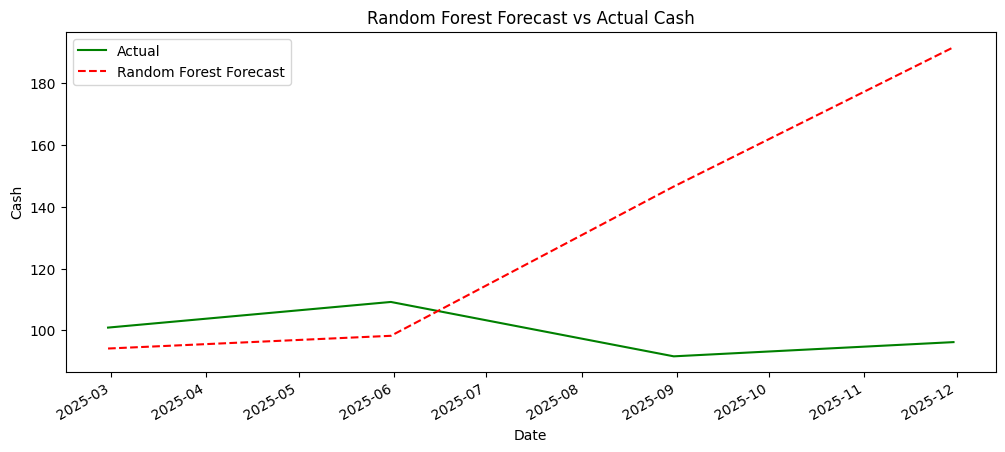

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label="Actual", color="green")
plt.plot(y_test.index, y_pred_level, label="Random Forest Forecast", linestyle="--", color="red")

plt.title("Random Forest Forecast vs Actual Cash")
plt.xlabel("Date")
plt.ylabel("Cash")
plt.legend()
plt.gcf().autofmt_xdate()
plt.show()